In [1]:
# Задание 1: Проверка окружения
import sys
import platform
import numpy as np
import pandas as pd

try:
    import sklearn
    print("✅ scikit-learn установлен")
except:
    sklearn = None
    print("❌ scikit-learn не установлен")

print("="*40)
print("Python:", sys.version.split()[0])
print("OS:", platform.platform())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
if sklearn:
    print("scikit-learn:", sklearn.__version__)
print("="*40)

✅ scikit-learn установлен
Python: 3.12.12
OS: Linux-6.6.113+-x86_64-with-glibc2.35
NumPy: 2.0.2
Pandas: 2.2.2
scikit-learn: 1.6.1


In [2]:
# Задание 3.1: Создаем случайную матрицу 100×5
np.random.seed(42)  # фиксируем seed для воспроизводимости

# Создаем матрицу 100x5 из случайных чисел
X = np.random.randn(100, 5)

print("X.shape:", X.shape)
print("X.dtype:", X.dtype)
print("\nПервые 5 строк матрицы X:")
print(X[:5])

X.shape: (100, 5)
X.dtype: float64

Первые 5 строк матрицы X:
[[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
 [-0.23413696  1.57921282  0.76743473 -0.46947439  0.54256004]
 [-0.46341769 -0.46572975  0.24196227 -1.91328024 -1.72491783]
 [-0.56228753 -1.01283112  0.31424733 -0.90802408 -1.4123037 ]
 [ 1.46564877 -0.2257763   0.0675282  -1.42474819 -0.54438272]]


In [3]:
# Задание 3.2: Статистики по матрице

# По всей матрице
overall_mean = X.mean()
overall_std = X.std()

# По столбцам (axis=0)
col_mean = X.mean(axis=0)
col_std = X.std(axis=0)
col_min = X.min(axis=0)
col_max = X.max(axis=0)

print("="*50)
print("СТАТИСТИКИ ПО ВСЕЙ МАТРИЦЕ:")
print(f"Среднее (mean): {overall_mean:.4f}")
print(f"Ст. отклонение (std): {overall_std:.4f}")

print("\n" + "="*50)
print("СТАТИСТИКИ ПО СТОЛБЦАМ:")
print("Столбец |   Mean   |   Std    |   Min    |   Max")
print("-"*50)

for i in range(5):
    print(f"   {i}    | {col_mean[i]:.4f}  | {col_std[i]:.4f}  | {col_min[i]:.4f}  | {col_max[i]:.4f}")

СТАТИСТИКИ ПО ВСЕЙ МАТРИЦЕ:
Среднее (mean): 0.0068
Ст. отклонение (std): 0.9803

СТАТИСТИКИ ПО СТОЛБЦАМ:
Столбец |   Mean   |   Std    |   Min    |   Max
--------------------------------------------------
   0    | -0.0447  | 0.8958  | -1.9521  | 2.3147
   1    | 0.0770  | 0.9792  | -2.3019  | 1.8862
   2    | -0.0939  | 0.9790  | -3.2413  | 2.1222
   3    | 0.1281  | 0.9547  | -1.9133  | 3.0789
   4    | -0.0322  | 1.0674  | -2.6197  | 3.8527


In [ ]:
# Задание 4.1: Линейная комбинация y = X @ w

# Создаем случайный вектор весов w (5 элементов)
w = np.random.randn(5)

# Вычисляем y = X @ w (матричное умножение)
y = X @ w

print("Вектор весов w:")
print(w)
print("\n" + "="*50)
print("Результат y = X @ w:")
print(f"Размерность y: {y.shape}")
print("\nПервые 10 значений y:")
print(y[:10])
print("\nСтатистики y:")
print(f"Среднее: {y.mean():.4f}")
print(f"Ст. отклонение: {y.std():.4f}")
print(f"Минимум: {y.min():.4f}")
print(f"Максимум: {y.max():.4f}")

In [4]:
# Задание 4.2: Метрики регрессии

# Создаем "истинные" веса
w_true = np.array([1.5, -2.0, 0.0, 0.7, 3.0])

# Добавляем немного шума к данным
noise = 0.1 * np.random.randn(X.shape[0])

# Истинные значения y_true
y_true = X @ w_true + noise

# Создаем "предсказанные" веса (немного отличаются от истинных)
w_guess = w_true + 0.5 * np.random.randn(5)

# Предсказанные значения y_pred
y_pred = X @ w_guess

# Вычисляем метрики
mse = np.mean((y_true - y_pred) ** 2)
mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(mse)

# R² (коэффициент детерминации)
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - y_true.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

print("="*60)
print("МЕТРИКИ КАЧЕСТВА РЕГРЕССИИ")
print("="*60)
print(f"MSE  (среднеквадратичная ошибка): {mse:.4f}")
print(f"MAE  (средняя абсолютная ошибка): {mae:.4f}")
print(f"RMSE (корень из MSE):            {rmse:.4f}")
print(f"R²   (коэффициент детерминации): {r2:.4f}")
print("="*60)

# Сравним истинные и предсказанные веса
print("\nСРАВНЕНИЕ ВЕСОВ:")
print("Столбец | Истинный w | Предсказанный w | Разница")
print("-"*50)
for i in range(5):
    diff = w_true[i] - w_guess[i]
    print(f"   {i}    |    {w_true[i]:.2f}     |      {w_guess[i]:.2f}      |  {diff:+.2f}")

МЕТРИКИ КАЧЕСТВА РЕГРЕССИИ
MSE  (среднеквадратичная ошибка): 0.9037
MAE  (средняя абсолютная ошибка): 0.7883
RMSE (корень из MSE):            0.9506
R²   (коэффициент детерминации): 0.9404

СРАВНЕНИЕ ВЕСОВ:
Столбец | Истинный w | Предсказанный w | Разница
--------------------------------------------------
   0    |    1.50     |      1.88      |  -0.38
   1    |    -2.00     |      -2.46      |  +0.46
   2    |    0.00     |      0.43      |  -0.43
   3    |    0.70     |      1.38      |  -0.68
   4    |    3.00     |      3.21      |  -0.21


In [6]:
# Задание 5.1: Создаем DataFrame из матрицы X

# Названия колонок
col_names = ['признак_1', 'признак_2', 'признак_3', 'признак_4', 'признак_5']

# Создаем DataFrame
df = pd.DataFrame(X, columns=col_names)

# Добавляем целевую переменную
df['target'] = y_true

print("="*60)
print("ЗАДАНИЕ 5.1: ПЕРВЫЕ 5 СТРОК DATAFRAME")
print("="*60)
display(df.head())

print("\n" + "="*60)
print("РАЗМЕРНОСТЬ DATAFRAME:")
print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")

ЗАДАНИЕ 5.1: ПЕРВЫЕ 5 СТРОК DATAFRAME


,признак_1,признак_2,признак_3,признак_4,признак_5,target
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,1.477878
1,-0.234137,1.579213,0.767435,-0.469474,0.542560,-2.019641
2,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-6.417573
3,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,-3.634000
4,1.465649,-0.225776,0.067528,-1.424748,-0.544383,-0.045510



РАЗМЕРНОСТЬ DATAFRAME:
Строк: 100, Столбцов: 6


In [7]:
# Задание 5.2: Описательные статистики и проверка пропусков

print("="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ (describe()):")
print("="*60)
display(df.describe())

print("\n" + "="*60)
print("ПРОВЕРКА НА ПРОПУСКИ (isnull().sum()):")
print("="*60)
print(df.isnull().sum())
print("\n✅ Пропусков нет! Отлично!")

ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ (describe()):


,признак_1,признак_2,признак_3,признак_4,признак_5,target
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,-0.044747,0.076954,-0.093874,0.128058,-0.032202,-0.239525
std,0.900352,0.984110,0.983943,0.959556,1.072806,3.915046
min,-1.952088,-2.301921,-3.241267,-1.913280,-2.619745,-9.355642
25%,-0.734897,-0.678136,-0.700307,-0.536288,-0.757046,-3.269099
50%,-0.010110,0.066421,-0.024662,0.152465,-0.145714,-0.976697
75%,0.524237,0.830645,0.532419,0.667929,0.648170,2.467806
max,2.314659,1.886186,2.122156,3.078881,3.852731,10.186734



ПРОВЕРКА НА ПРОПУСКИ (isnull().sum()):
признак_1    0
признак_2    0
признак_3    0
признак_4    0
признак_5    0
target       0
dtype: int64

✅ Пропусков нет! Отлично!


In [8]:
# Задание 5.3: Фильтрация, сортировка и группировка

print("="*60)
print("ПРИМЕР ФИЛЬТРАЦИИ:")
print("Объекты, где признак_1 > 0 (отрицательные значения)")
print("-"*40)

# Фильтруем строки, где признак_1 больше 0
filtered_df = df[df['признак_1'] > 0]
print(f"Найдено {len(filtered_df)} строк из {len(df)}")
print("\nПервые 5 отфильтрованных строк (сортировка по target):")
display(filtered_df.sort_values('target', ascending=False).head())

print("\n" + "="*60)
print("СОЗДАНИЕ КАТЕГОРИАЛЬНОГО СТОЛБЦА (бины по признаку_1):")
print("="*60)

# Создаем 4 категории (бины) для признака_1
df['категория'] = pd.cut(df['признак_1'], bins=4, labels=['Низкий', 'Средне-низкий', 'Средне-высокий', 'Высокий'])

print("Первые 10 строк с новой категорией:")
display(df[['признак_1', 'категория', 'target']].head(10))

print("\n" + "="*60)
print("ГРУППИРОВКА ПО КАТЕГОРИЯМ:")
print("Среднее значение target в каждой категории")
print("="*60)

grouped = df.groupby('категория')['target'].agg(['mean', 'std', 'count'])
display(grouped)

ПРИМЕР ФИЛЬТРАЦИИ:
Объекты, где признак_1 > 0 (отрицательные значения)
----------------------------------------
Найдено 49 строк из 100

Первые 5 отфильтрованных строк (сортировка по target):


,признак_1,признак_2,признак_3,признак_4,признак_5,target
35,0.827183,0.013002,1.453534,-0.264657,2.720169,9.194759
47,0.633919,-2.025143,0.186454,-0.661786,0.852433,7.074909
74,0.024510,0.497998,1.451144,0.959271,2.153182,6.254746
11,0.931280,-0.839218,-0.309212,0.331263,0.975545,6.228851
82,0.711615,-1.124642,-1.534114,1.277677,0.332314,5.271300



СОЗДАНИЕ КАТЕГОРИАЛЬНОГО СТОЛБЦА (бины по признаку_1):
Первые 10 строк с новой категорией:


,признак_1,категория,target
0,0.496714,Средне-высокий,1.477878
1,-0.234137,Средне-низкий,-2.019641
2,-0.463418,Средне-низкий,-6.417573
3,-0.562288,Средне-низкий,-3.634000
4,1.465649,Высокий,-0.045510
5,0.110923,Средне-низкий,1.124130
6,-0.601707,Средне-низкий,-2.939119
7,-1.220844,Низкий,-2.674538
8,0.738467,Средне-высокий,-3.876523
9,-0.719844,Средне-низкий,-5.290171



ГРУППИРОВКА ПО КАТЕГОРИЯМ:
Среднее значение target в каждой категории


/tmp/ipykernel_359/1117323396.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('категория')['target'].agg(['mean', 'std', 'count'])


,mean,std,count
категория,,,
Низкий,-1.132016,4.321215,18
Средне-низкий,-0.741761,3.683542,42
Средне-высокий,0.381615,4.273853,31
Высокий,1.749742,1.703047,9


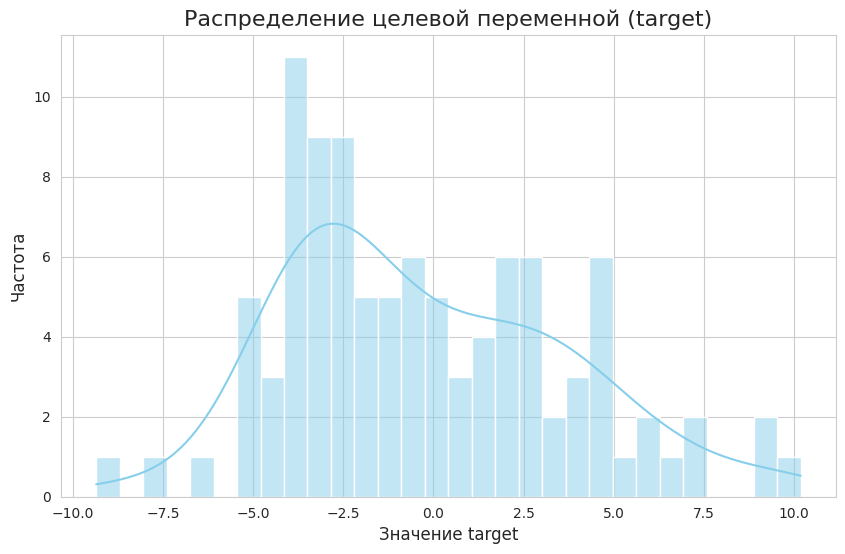

Статистика по target:
Среднее: -0.2395
Медиана: -0.9767
Станд. отклонение: 3.9150


In [9]:
# Задание 6.1: Гистограмма распределения target

import matplotlib.pyplot as plt
import seaborn as sns

# Настраиваем красивый стиль графиков
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Строим гистограмму
sns.histplot(df['target'], bins=30, kde=True, color='skyblue')

# Добавляем подписи и заголовок
plt.title('Распределение целевой переменной (target)', fontsize=16)
plt.xlabel('Значение target', fontsize=12)
plt.ylabel('Частота', fontsize=12)

# Показываем график
plt.show()

# Добавим немного статистики
print("Статистика по target:")
print(f"Среднее: {df['target'].mean():.4f}")
print(f"Медиана: {df['target'].median():.4f}")
print(f"Станд. отклонение: {df['target'].std():.4f}")

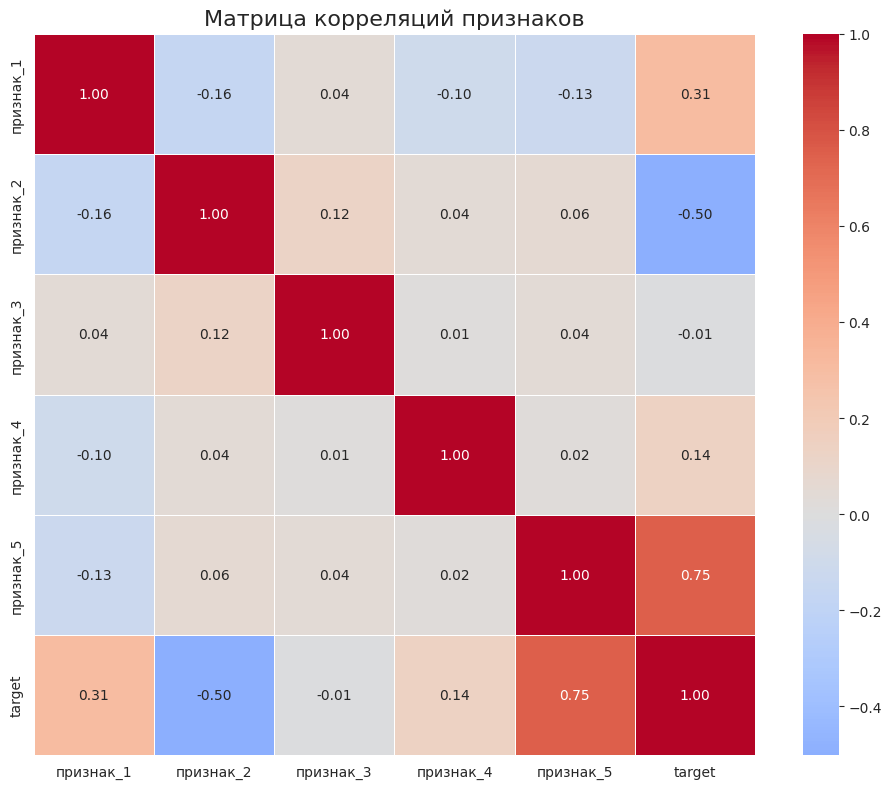

🔍 Анализ корреляций:
- Чем ближе к 1, тем сильнее прямая связь
- Чем ближе к -1, тем сильнее обратная связь
- Чем ближе к 0, тем слабее связь


In [10]:
# Задание 6.2: Тепловая карта корреляций

plt.figure(figsize=(10, 8))

# Выбираем только числовые колонки для корреляции
numeric_cols = ['признак_1', 'признак_2', 'признак_3', 'признак_4', 'признак_5', 'target']
corr_matrix = df[numeric_cols].corr()

# Рисуем тепловую карту
sns.heatmap(corr_matrix,
            annot=True,           # показывать числа в ячейках
            fmt='.2f',             # формат чисел (2 знака после запятой)
            cmap='coolwarm',       # цветовая схема
            center=0,              # центр цветовой шкалы в 0
            square=True,           # квадратные ячейки
            linewidths=0.5)        # линии между ячейками

plt.title('Матрица корреляций признаков', fontsize=16)
plt.tight_layout()
plt.show()

print("🔍 Анализ корреляций:")
print("- Чем ближе к 1, тем сильнее прямая связь")
print("- Чем ближе к -1, тем сильнее обратная связь")
print("- Чем ближе к 0, тем слабее связь")

In [11]:
# Задание 7 (Бонус): Iris dataset и простая модель

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 7.1 Загружаем данные
print("="*60)
print("ЗАГРУЗКА ДАТАСЕТА IRIS")
print("="*60)

iris = load_iris(as_frame=True)
iris_df = iris.frame

print("Первые 5 строк:")
display(iris_df.head())

print("\nИнформация о датасете:")
print(f"Количество объектов: {iris_df.shape[0]}")
print(f"Количество признаков: {iris_df.shape[1] - 1}")  # -1 потому что target не признак
print(f"Названия признаков: {iris.feature_names}")
print(f"Названия классов: {iris.target_names}")

ЗАГРУЗКА ДАТАСЕТА IRIS
Первые 5 строк:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



Информация о датасете:
Количество объектов: 150
Количество признаков: 4
Названия признаков: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Названия классов: ['setosa' 'versicolor' 'virginica']



РАСПРЕДЕЛЕНИЕ КЛАССОВ
Класс 0 (setosa): 50 объектов
Класс 1 (versicolor): 50 объектов
Класс 2 (virginica): 50 объектов


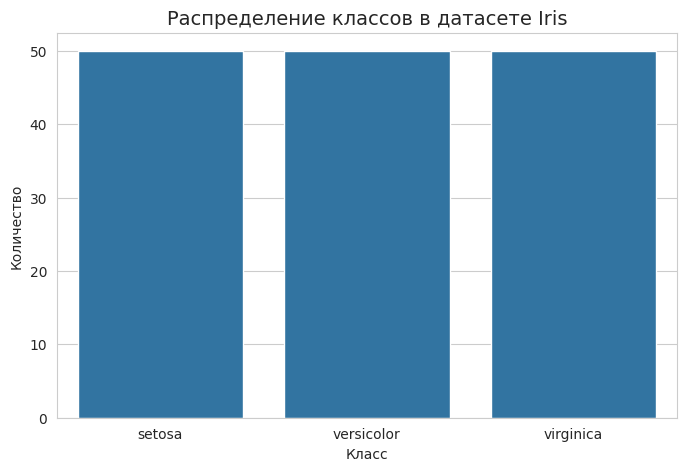

In [12]:
# 7.2 Распределение классов
print("\n" + "="*60)
print("РАСПРЕДЕЛЕНИЕ КЛАССОВ")
print("="*60)

class_dist = iris_df['target'].value_counts().sort_index()
for i in range(3):
    print(f"Класс {i} ({iris.target_names[i]}): {class_dist[i]} объектов")

# Визуализация распределения классов
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=iris_df, x='target')
plt.title('Распределение классов в датасете Iris', fontsize=14)
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.xticks(ticks=[0, 1, 2], labels=iris.target_names)
plt.show()

РАЗМЕРЫ ВЫБОРОК:
Обучающая выборка: 120 объектов
Тестовая выборка: 30 объектов

ОЦЕНКА КАЧЕСТВА МОДЕЛИ
Accuracy (точность): 0.9667
Это означает, что модель правильно предсказала 96.7% цветов

МАТРИЦА ОШИБОК (Confusion Matrix):
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


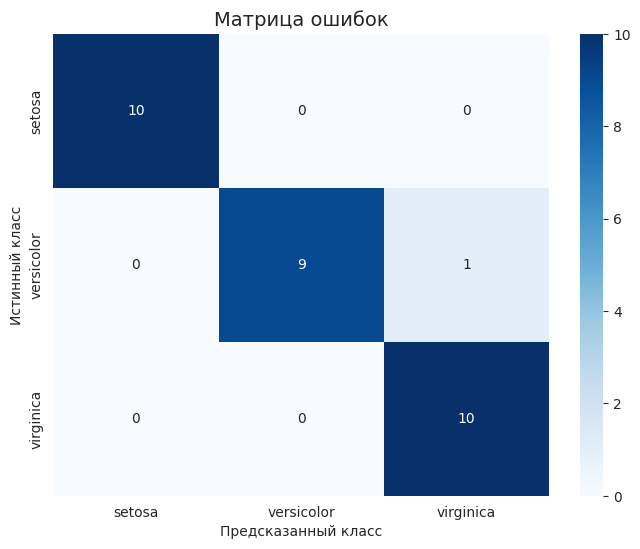


ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССАМ:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [13]:
# 7.3 Разделение на train/test и обучение модели

# Подготовка данных
X_iris = iris_df.drop(columns=['target'])
y_iris = iris_df['target']

# Разделяем на обучающую и тестовую выборки (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

print("="*60)
print("РАЗМЕРЫ ВЫБОРОК:")
print("="*60)
print(f"Обучающая выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка: {X_test.shape[0]} объектов")

# Создаем и обучаем модель
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Предсказания
y_pred = model.predict(X_test)

# Оценка качества
print("\n" + "="*60)
print("ОЦЕНКА КАЧЕСТВА МОДЕЛИ")
print("="*60)
print(f"Accuracy (точность): {accuracy_score(y_test, y_pred):.4f}")
print(f"Это означает, что модель правильно предсказала {accuracy_score(y_test, y_pred)*100:.1f}% цветов")

print("\n" + "="*60)
print("МАТРИЦА ОШИБОК (Confusion Matrix):")
print("="*60)
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Красивая визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Матрица ошибок', fontsize=14)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

print("\n" + "="*60)
print("ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССАМ:")
print("="*60)
print(classification_report(y_test, y_pred, target_names=iris.target_names))